# Deutsch-Jozsa Algorithm: Where Classical Fails & Quantum Wins
### *Real-World Problem: Factory Sensor Fault Detection*

---

> **The Setup:** A smart factory has thousands of sensors. Each sensor runs a diagnostic function. Your job: figure out if each sensor's function is **broken** (always returns the same value, "constant") or **working correctly** (returns different values for different inputs, "balanced").
> A broken sensor stuck on ALERT is just as dangerous as one stuck on CLEAR.


## Query Count Comparison

| Input Size | Classical Worst Case | Deutsch-Jozsa |
|---|---|---|
| 4 inputs | 3 queries | **1 query** |
| 8 inputs | 5 queries | **1 query** |
| 16 inputs | 9 queries | **1 query** |
| 1,000 inputs | 501 queries | **1 query** |
| 1,000,000 inputs | 500,001 queries | **1 query** |

In [1]:
import subprocess, sys
for pkg in ['qiskit', 'qiskit-aer', 'matplotlib', 'pylatexenc', 'numpy']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Ready!')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


Ready!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'monospace'
SIM = AerSimulator()

print('All imports loaded. Qiskit Aer simulator ready.')

All imports loaded. Qiskit Aer simulator ready.


---
## Section 1: The Real-World Problem — Sensor Fault Detection

### The Scenario

We are quality engineer at a factory. Each sensor has a **diagnostic function** `f(x)` that takes a sensor reading code `x` (0 to N-1) and returns 0 or 1.

- **Constant sensor (BROKEN):** `f(x)` returns the same value (always 0 or always 1) no matter what reading you feed it. The sensor is stuck it can't distinguish between safe and unsafe states.
- **Balanced sensor (WORKING):** `f(x)` returns 0 for exactly half the inputs and 1 for the other half. The sensor responds differently to different conditions it's doing its job.

### Why This Matters

A constant sensor that always says "CLEAR" won't alert you to real danger. A constant sensor that always says "ALERT" floods you with false alarms and gets ignored. Both are catastrophic in a nuclear plant, aircraft, or medical device.

**Classical audit:** Test each sensor code one by one. With 1024 sensor codes, you might need 513 tests before you're certain.

**Quantum audit (Deutsch-Jozsa):** One quantum query. Always. No matter how many sensor codes.

In [4]:
# ─── Classical Sensor Audit ──────────────────────────────────────────────────

import random

def make_sensor_function(n_bits, kind='balanced', seed=42):
    """
    Simulate a sensor diagnostic function.
    n_bits: number of input bits (2^n_bits inputs)
    kind: 'constant_0', 'constant_1', or 'balanced'
    Returns a dict mapping input -> output.
    """
    N = 2 ** n_bits
    random.seed(seed)
    
    if kind == 'constant_0':
        return {i: 0 for i in range(N)}, 'constant'
    elif kind == 'constant_1':
        return {i: 1 for i in range(N)}, 'constant'
    else:  # balanced
        inputs = list(range(N))
        random.shuffle(inputs)
        func = {}
        for idx, x in enumerate(inputs):
            func[x] = 0 if idx < N // 2 else 1
        return func, 'balanced'


def classical_audit(func, n_inputs, verbose=True):
    """
    Classical approach: query one input at a time until certain.
    Returns (verdict, queries_used).
    """
    first_val = func[0]
    queries = 1
    
    if verbose:
        print(f'  Query 0 → f(0) = {first_val}')
    
    for i in range(1, n_inputs):
        queries += 1
        result = func[i]
        
        if verbose and i <= 5:
            print(f'  Query {i} → f({i}) = {result}', end='')
        
        if result != first_val:
            if verbose:
                print(f'  ← DIFFERENCE FOUND! Oracle is BALANCED.')
            return 'balanced', queries
        
        if verbose and i <= 5:
            print(f'  (still same)')
        if verbose and i == 6:
            print(f'  ... (continuing to query ...)')
    
    if verbose:
        print(f'  All {n_inputs} inputs checked — all returned {first_val}. Oracle is CONSTANT.')
    return 'constant', queries


# Demo on a 3-bit (8 input) balanced sensor
n_bits = 3
N = 2 ** n_bits

print(f'=== Classical audit of a BALANCED sensor (n={n_bits}, {N} inputs) ===')
func_bal, true_type = make_sensor_function(n_bits, 'balanced')
verdict, queries = classical_audit(func_bal, N, verbose=True)
print(f'\n  Verdict: {verdict.upper()} | Queries used: {queries} / {N}')

print(f'\n=== Classical audit of a CONSTANT sensor (n={n_bits}, {N} inputs) ===')
func_const, _ = make_sensor_function(n_bits, 'constant_0')
verdict2, queries2 = classical_audit(func_const, N, verbose=True)
print(f'\n  Verdict: {verdict2.upper()} | Queries used: {queries2} / {N} — HAD to check all!')

=== Classical audit of a BALANCED sensor (n=3, 8 inputs) ===
  Query 0 → f(0) = 1
  Query 1 → f(1) = 1  (still same)
  Query 2 → f(2) = 1  (still same)
  Query 3 → f(3) = 0  ← DIFFERENCE FOUND! Oracle is BALANCED.

  Verdict: BALANCED | Queries used: 4 / 8

=== Classical audit of a CONSTANT sensor (n=3, 8 inputs) ===
  Query 0 → f(0) = 0
  Query 1 → f(1) = 0  (still same)
  Query 2 → f(2) = 0  (still same)
  Query 3 → f(3) = 0  (still same)
  Query 4 → f(4) = 0  (still same)
  Query 5 → f(5) = 0  (still same)
  ... (continuing to query ...)
  All 8 inputs checked — all returned 0. Oracle is CONSTANT.

  Verdict: CONSTANT | Queries used: 8 / 8 — HAD to check all!


In [5]:
# ─── Show How Classical Queries Explode with Scale ──────────────────────────

print('Classical worst-case query count (constant oracle, must check n/2 + 1):\n')
print(f'{"n_bits":<10} {"Inputs (N)":<14} {"Worst-case queries":<22} {"Quantum queries"}')
print('─' * 60)

for nb in [1, 2, 3, 4, 8, 10, 16, 20]:
    n_in = 2 ** nb
    worst = n_in // 2 + 1
    print(f'{nb:<10} {n_in:<14,} {worst:<22,} 1')

print('\n→ Classical grows exponentially. Quantum stays at 1. Always.')

Classical worst-case query count (constant oracle, must check n/2 + 1):

n_bits     Inputs (N)     Worst-case queries     Quantum queries
────────────────────────────────────────────────────────────
1          2              2                      1
2          4              3                      1
3          8              5                      1
4          16             9                      1
8          256            129                    1
10         1,024          513                    1
16         65,536         32,769                 1
20         1,048,576      524,289                1

→ Classical grows exponentially. Quantum stays at 1. Always.


---
## Section 2: The Quantum Circuit

The Deutsch-Jozsa circuit has 3 parts:
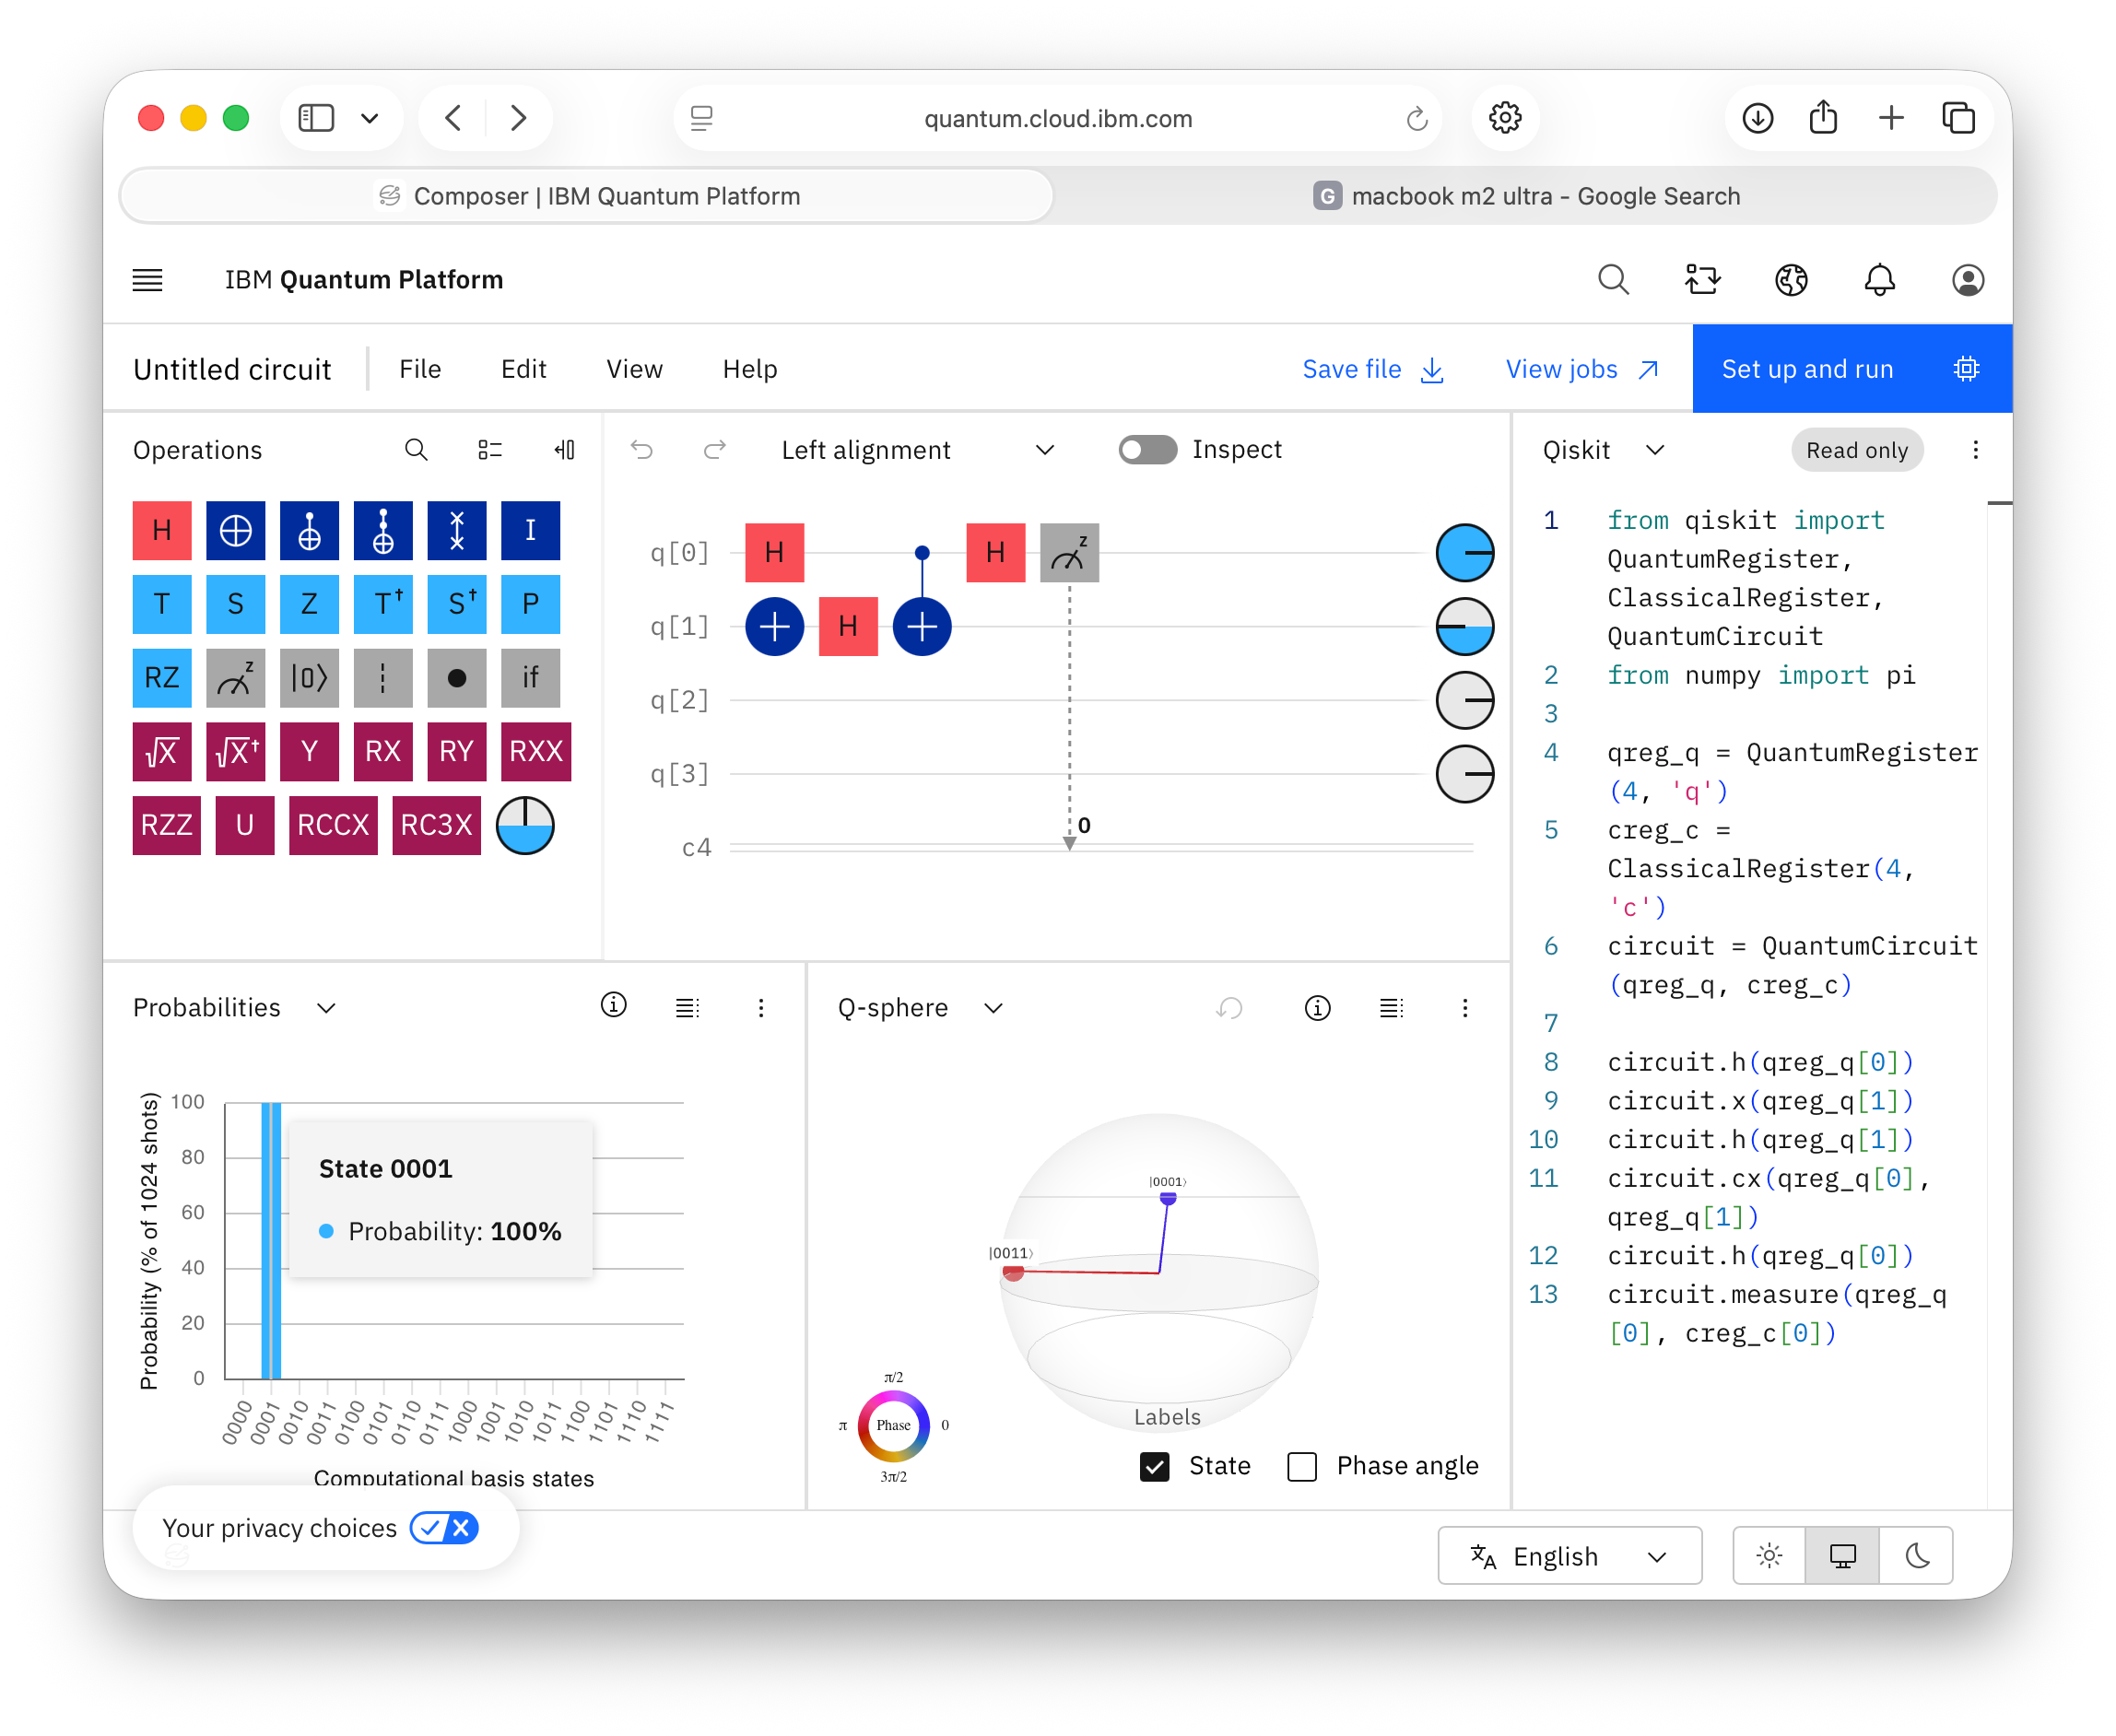

1. **Hadamard (H) on all qubits:** Creates superposition — all inputs exist simultaneously
2. **Oracle gate:** Encodes f(x) — the sensor's diagnostic function — into phase
3. **Hadamard again on data qubits:** Interference! Constant → all qubits return to |0⟩. Balanced → they don't.
4. **Measure:** If you see all zeros → constant. Anything else → balanced.

### Why does this work?

The two Hadamard layers + oracle create **destructive interference** for "wrong" answers and **constructive interference** for the "right" one. Think noise-cancelling headphones: the algorithm amplifies the signal (constant vs balanced) and cancels out everything else.

In [1]:
# ─── Build Quantum Oracles ────────────────────────────────────────────────────

def build_constant_oracle(n, output_val=0):
    """
    Constant oracle: f(x) = output_val for ALL x.
    If output_val=1, flip the ancilla (qubit n). Otherwise do nothing.
    """
    qc = QuantumCircuit(n + 1)  # n data qubits + 1 ancilla
    if output_val == 1:
        qc.x(n)  # Flip ancilla unconditionally
    # output_val=0 → do nothing (identity)
    return qc


def build_balanced_oracle(n, seed=42):
    """
    Balanced oracle: f(x) = 0 for half the inputs, 1 for the other half.
    Implementation: randomly choose a subset of data qubits to CNOT into the ancilla.
    This creates a balanced function via XOR of selected input bits.
    """
    random.seed(seed)
    qc = QuantumCircuit(n + 1)
    
    # Choose a random non-zero bitmask (which qubits to XOR)
    mask = random.randint(1, 2**n - 1)  # Non-zero to ensure balanced
    
    for i in range(n):
        if mask & (1 << i):  # If bit i is set in the mask
            qc.cx(i, n)  # CNOT: data[i] → ancilla
    
    return qc


def build_dj_circuit(n, oracle_type='balanced', seed=42, measure=True):
    """
    Full Deutsch-Jozsa circuit.
    n: number of data input qubits
    oracle_type: 'constant_0', 'constant_1', or 'balanced'
    """
    data  = QuantumRegister(n,   name='x')
    anc   = QuantumRegister(1,   name='anc')
    cl    = ClassicalRegister(n, name='out')
    qc    = QuantumCircuit(data, anc, cl)
    
    # ── Step 1: Initialize ancilla to |1⟩
    qc.x(anc[0])
    qc.barrier(label='init')
    
    # ── Step 2: Hadamard on all qubits (create superposition)
    qc.h(data)
    qc.h(anc[0])
    qc.barrier(label='|ψ⟩')
    
    # ── Step 3: Oracle (the sensor's diagnostic function)
    if oracle_type == 'constant_0':
        oracle = build_constant_oracle(n, 0)
    elif oracle_type == 'constant_1':
        oracle = build_constant_oracle(n, 1)
    else:
        oracle = build_balanced_oracle(n, seed)
    
    qc.compose(oracle, inplace=True)
    qc.barrier(label='oracle')
    
    # ── Step 4: Hadamard on data qubits (interference)
    qc.h(data)
    qc.barrier(label='interfere')
    
    # ── Step 5: Measure data qubits
    if measure:
        qc.measure(data, cl)
    
    return qc



---
## Section 3: Reading the Measurement

After the circuit runs, we measure the data qubits. The rule is dead simple:

| Measurement outcome | Meaning |
|---|---|
| All zeros: `000...0` | Oracle is **CONSTANT** |
| Anything else (any 1) | Oracle is **BALANCED** |

No probabilities. No uncertainty. A deterministic answer from a quantum circuit.

In [5]:
!pip3 install QuantumRegister

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement QuantumRegister (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
ERROR: No matching distribution found for QuantumRegister


In [7]:
# ─── Run DJ and Interpret Results ─────────────────────────────────────────────

def run_dj(n, oracle_type, seed=42, shots=1024, verbose=True):
    """
    Run the Deutsch-Jozsa circuit and return verdict + counts.
    """
    qc = build_dj_circuit(n, oracle_type, seed, measure=True)
    result = SIM.run(qc, shots=shots).result()
    counts = result.get_counts()
    
    all_zeros = '0' * n
    is_constant = (max(counts, key=counts.get) == all_zeros)
    verdict = 'constant' if is_constant else 'balanced'
    
    if verbose:
        top = max(counts, key=counts.get)
        print(f'  Oracle type : {oracle_type}')
        print(f'  Top outcome : |{top}⟩ ({counts[top]}/{shots} shots)')
        print(f'  DJ verdict  : {verdict.upper()} sensor')
        if verdict == oracle_type.split("_")[0] or (verdict == 'constant' and 'constant' in oracle_type):
            print(f'  Correct?    : ✅ YES')
    
    return verdict, counts


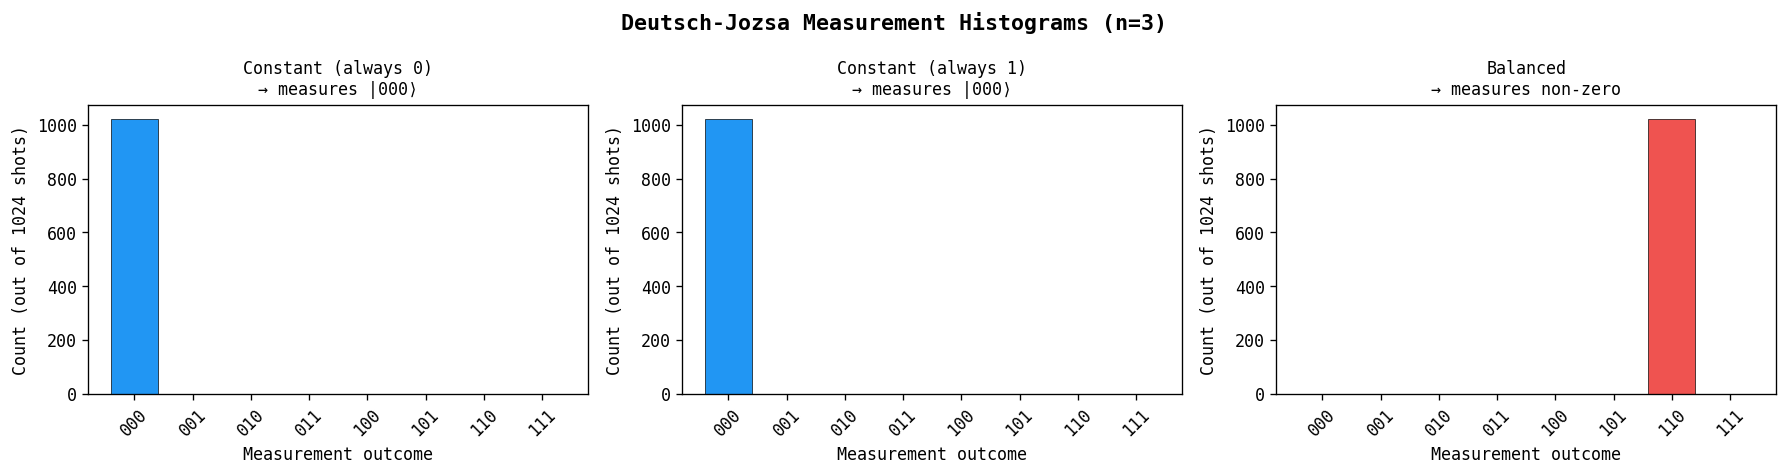


Key insight: ALL shots land on |000⟩ for constant oracles.
For balanced, the probability of getting |000⟩ is exactly 0. Perfect discrimination.


In [9]:
# ─── Side-by-Side Histograms: Constant vs Balanced ─────────────────────────

n = 3
_, counts_const   = run_dj(n, 'constant_0',  verbose=False)
_, counts_const1  = run_dj(n, 'constant_1',  verbose=False)
_, counts_balanced = run_dj(n, 'balanced',   verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Deutsch-Jozsa Measurement Histograms (n=3)', fontsize=13, fontweight='bold')

for ax, counts, title, color in [
    (axes[0], counts_const,    'Constant (always 0)\n→ measures |000⟩', '#2196F3'),
    (axes[1], counts_const1,   'Constant (always 1)\n→ measures |000⟩', '#2196F3'),
    (axes[2], counts_balanced, 'Balanced\n→ measures non-zero',          '#EF5350'),
]:
    all_states = [format(i, f'0{n}b') for i in range(2**n)]
    vals = [counts.get(s, 0) for s in all_states]
    colors_bar = [color if (s == '000') == (color == '#2196F3') else '#aaaaaa' for s in all_states]

    ax.bar(all_states, vals, color=colors_bar, edgecolor='black', linewidth=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Measurement outcome')
    ax.set_ylabel('Count (out of 1024 shots)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nKey insight: ALL shots land on |000⟩ for constant oracles.')
print('For balanced, the probability of getting |000⟩ is exactly 0. Perfect discrimination.')

---
## 🏁 Section 4: The Race — Classical vs Quantum

This is the main event. We simulate:
1. **Classical solver** auditing a sensor, counting queries until certain
2. **Deutsch-Jozsa** answering in exactly 1 query

We run this for many input sizes and plot the query count side by side.

Running the Classical vs Quantum race across sensor sizes...

n_bits   Inputs     Classical (worst)      D-J queries     Speedup
─────────────────────────────────────────────────────────────────
1        2          2                      1               2x
2        4          3                      1               3x
3        8          5                      1               5x
4        16         9                      1               9x
5        32         17                     1               17x
6        64         33                     1               33x
7        128        65                     1               65x
8        256        129                    1               129x


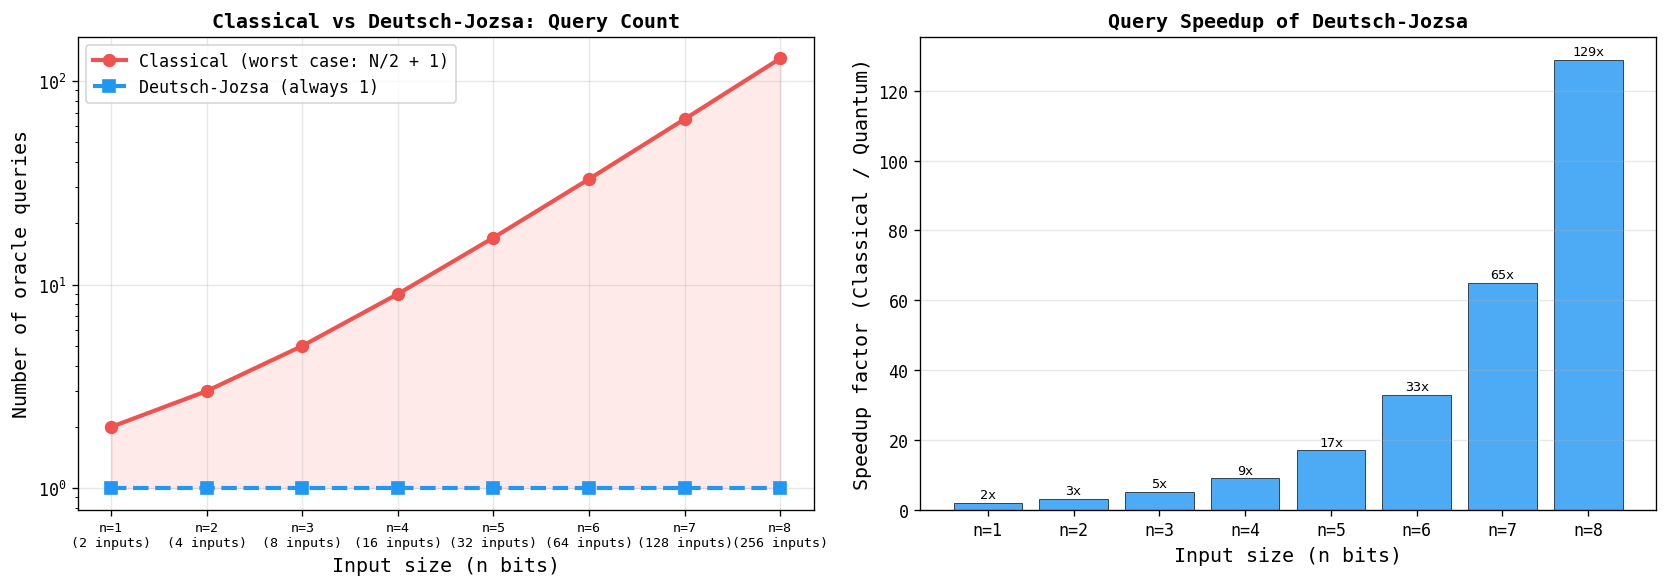


The gap grows exponentially. Classical needs N/2+1 queries. Quantum needs 1. Always.


In [10]:
# ─── The Big Race ─────────────────────────────────────────────────────────────

print('Running the Classical vs Quantum race across sensor sizes...\n')
print(f'{"n_bits":<8} {"Inputs":<10} {"Classical (worst)":<22} {"D-J queries":<15} {"Speedup"}')
print('─' * 65)

n_bits_range = list(range(1, 9))
classical_worst = []
dj_queries      = []

for nb in n_bits_range:
    N = 2 ** nb
    worst = N // 2 + 1
    classical_worst.append(worst)
    dj_queries.append(1)
    speedup = worst
    print(f'{nb:<8} {N:<10} {worst:<22} {1:<15} {speedup}x')

# ─── Plot the Race ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Query count comparison
x = n_bits_range
ax1.fill_between(x, classical_worst, 1, alpha=0.12, color='#EF5350')
ax1.plot(x, classical_worst, 'o-', color='#EF5350', linewidth=2.5, markersize=7,
         label='Classical (worst case: N/2 + 1)')
ax1.plot(x, dj_queries, 's--', color='#2196F3', linewidth=2.5, markersize=7,
         label='Deutsch-Jozsa (always 1)')
ax1.set_xlabel('Input size (n bits)', fontsize=12)
ax1.set_ylabel('Number of oracle queries', fontsize=12)
ax1.set_title('Classical vs Deutsch-Jozsa: Query Count', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels([f'n={nb}\n({2**nb} inputs)' for nb in x], fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Right: The gap — speedup factor
speedups = classical_worst
bars = ax2.bar(x, speedups, color='#2196F3', alpha=0.8, edgecolor='black', linewidth=0.5)
for bar, sp in zip(bars, speedups):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{sp}x', ha='center', va='bottom', fontsize=8)
ax2.set_xlabel('Input size (n bits)', fontsize=12)
ax2.set_ylabel('Speedup factor (Classical / Quantum)', fontsize=12)
ax2.set_title('Query Speedup of Deutsch-Jozsa', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'n={nb}' for nb in x])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nThe gap grows exponentially. Classical needs N/2+1 queries. Quantum needs 1. Always.')

---
## 🔬 Section 5: Visualizing the Quantum Magic — Statevector Evolution

Let's see exactly what happens to the qubit state at each step of the circuit.
This is the "noise-cancelling headphones" effect made visible.

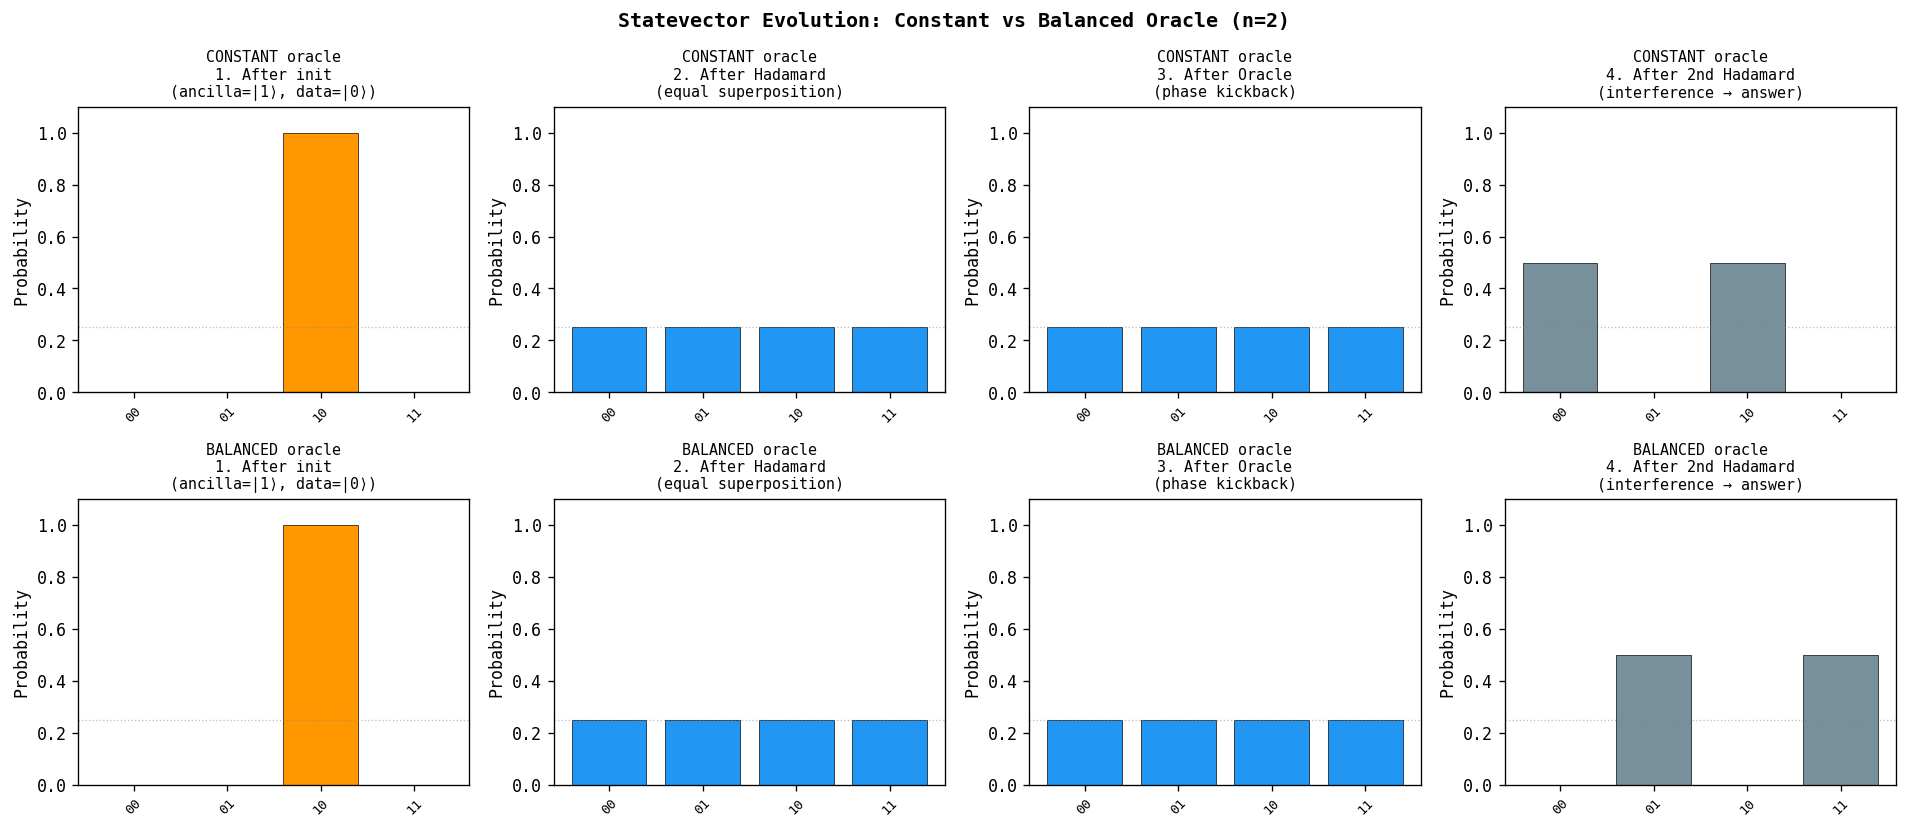


🔑 Key observation:
  - After the 2nd Hadamard (interference step):
  - CONSTANT oracle → ALL probability collapses into |00⟩ (all zeros)
  - BALANCED oracle → |00⟩ probability drops to ZERO, spreads to other states
  This is destructive/constructive interference doing the work.


In [11]:
# ─── Step-by-Step Statevector for n=2 ────────────────────────────────────────

def get_statevector_after_step(n, oracle_type, up_to_barrier):
    """
    Build a partial DJ circuit up to a given stage and return its statevector.
    up_to_barrier: 'init', 'superposition', 'oracle', 'interference'
    """
    qc = QuantumCircuit(n + 1)
    
    # Step 1: init ancilla
    qc.x(n)
    if up_to_barrier == 'init':
        return Statevector.from_instruction(qc)
    
    # Step 2: Hadamard
    for i in range(n + 1):
        qc.h(i)
    if up_to_barrier == 'superposition':
        return Statevector.from_instruction(qc)
    
    # Step 3: Oracle
    if oracle_type.startswith('constant'):
        val = int(oracle_type.split('_')[1])
        oracle = build_constant_oracle(n, val)
    else:
        oracle = build_balanced_oracle(n)
    qc.compose(oracle, inplace=True)
    if up_to_barrier == 'oracle':
        return Statevector.from_instruction(qc)
    
    # Step 4: Hadamard again
    for i in range(n):
        qc.h(i)
    return Statevector.from_instruction(qc)


def plot_probabilities(sv, n, title, ax):
    """Plot measurement probabilities of the data qubits."""
    probs = sv.probabilities()
    n_total = n + 1
    N_full  = 2 ** n_total
    
    # Sum over ancilla states to get marginal probs for data qubits
    data_states = [format(i, f'0{n}b') for i in range(2**n)]
    marginal = {s: 0.0 for s in data_states}
    for full_idx in range(N_full):
        bits = format(full_idx, f'0{n_total}b')
        data_bits = bits[:n]
        marginal[data_bits] += probs[full_idx]
    
    vals = [marginal[s] for s in data_states]
    colors_bar = ['#2196F3' if abs(v - 1.0/len(data_states)) < 0.01 else '#FF9800'
                  if v > 0.5 else '#78909C' for v in vals]
    ax.bar(data_states, vals, color=colors_bar, edgecolor='black', linewidth=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.axhline(y=1.0/len(data_states), color='gray', linestyle=':', alpha=0.5, linewidth=0.8)


n = 2  # Use n=2 so we can visualize easily
stages = ['init', 'superposition', 'oracle', 'interference']
stage_labels = [
    '1. After init\n(ancilla=|1⟩, data=|0⟩)',
    '2. After Hadamard\n(equal superposition)',
    '3. After Oracle\n(phase kickback)',
    '4. After 2nd Hadamard\n(interference → answer)'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Statevector Evolution: Constant vs Balanced Oracle (n=2)', fontsize=12, fontweight='bold')

for oracle_row, oracle_type in enumerate(['constant_0', 'balanced']):
    for col, (stage, label) in enumerate(zip(stages, stage_labels)):
        sv = get_statevector_after_step(n, oracle_type, stage)
        ax = axes[oracle_row][col]
        oracle_label = 'CONSTANT' if 'constant' in oracle_type else 'BALANCED'
        full_title = f'{oracle_label} oracle\n{label}'
        plot_probabilities(sv, n, full_title, ax)

plt.tight_layout()
plt.show()

print('\n🔑 Key observation:')
print('  - After the 2nd Hadamard (interference step):')
print('  - CONSTANT oracle → ALL probability collapses into |00⟩ (all zeros)')
print('  - BALANCED oracle → |00⟩ probability drops to ZERO, spreads to other states')
print('  This is destructive/constructive interference doing the work.')

---
## 🏭 Section 6: The Full Factory Audit Simulation

Now let's run the complete real-world scenario: auditing a batch of factory sensors.

In [12]:
# ─── Factory Sensor Audit Simulation ─────────────────────────────────────────

# 12 sensors to audit, each with a randomly assigned oracle type
random.seed(2024)

sensor_types = [
    random.choice(['constant_0', 'constant_1', 'balanced'])
    for _ in range(12)
]

n_bits = 4  # Each sensor has 16 diagnostic codes
N = 2 ** n_bits

print('=== Factory Sensor Audit: 12 Sensors, 16 codes each ===')
print(f'n_bits = {n_bits}, N = {N} inputs per sensor\n')
print(f'{"Sensor":<10} {"True Type":<18} {"Classical Queries":<22} {"D-J Queries":<15} {"D-J Verdict":<18} {"Correct?"}')
print('─' * 90)

total_classical = 0
total_quantum = 0

for idx, stype in enumerate(sensor_types):
    sensor_id = f'S-{idx+1:02d}'
    true_label = 'CONSTANT' if 'constant' in stype else 'BALANCED'
    
    # Classical audit
    func, _ = make_sensor_function(n_bits, stype if stype=='balanced' else 'constant_'+stype[-1], seed=idx)
    c_verdict, c_queries = classical_audit(func, N, verbose=False)
    total_classical += c_queries
    
    # Quantum audit
    q_verdict, _ = run_dj(n_bits, stype, seed=idx, verbose=False)
    total_quantum += 1
    
    correct = '✅' if q_verdict == ('constant' if 'constant' in stype else 'balanced') else '❌'
    print(f'{sensor_id:<10} {true_label:<18} {c_queries:<22} {1:<15} {q_verdict.upper():<18} {correct}')

print('─' * 90)
print(f'{"TOTAL":<10} {"":<18} {total_classical:<22} {total_quantum:<15}')
print(f'\nClassical: {total_classical} queries | Quantum: {total_quantum} queries')
print(f'Quantum savings: {total_classical - total_quantum} fewer queries ({total_classical/total_quantum:.1f}x speedup)')

=== Factory Sensor Audit: 12 Sensors, 16 codes each ===
n_bits = 4, N = 16 inputs per sensor

Sensor     True Type          Classical Queries      D-J Queries     D-J Verdict        Correct?
──────────────────────────────────────────────────────────────────────────────────────────
S-01       CONSTANT           16                     1               CONSTANT           ✅
S-02       CONSTANT           16                     1               CONSTANT           ✅
S-03       BALANCED           2                      1               BALANCED           ✅
S-04       BALANCED           2                      1               BALANCED           ✅
S-05       CONSTANT           16                     1               CONSTANT           ✅
S-06       CONSTANT           16                     1               CONSTANT           ✅
S-07       BALANCED           2                      1               BALANCED           ✅
S-08       CONSTANT           16                     1               CONSTANT           

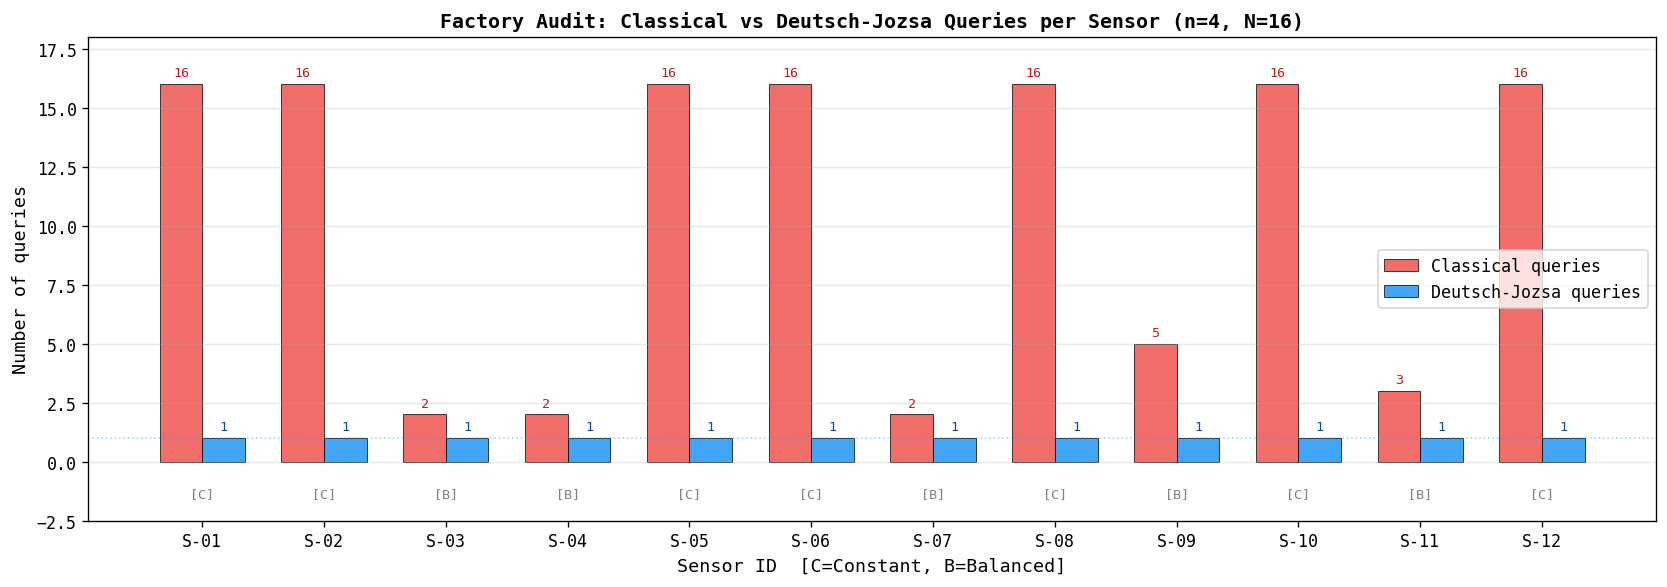


Total classical: 126 queries
Total quantum  : 12 queries (1 per sensor)
Ratio          : 10.5x faster overall


In [13]:
# ─── Final Visualization: Audit Query Comparison ─────────────────────────────

sensor_ids = [f'S-{i+1:02d}' for i in range(12)]
classical_per_sensor = []
for idx, stype in enumerate(sensor_types):
    func, _ = make_sensor_function(n_bits, stype if stype=='balanced' else 'constant_'+stype[-1], seed=idx)
    _, cq = classical_audit(func, N, verbose=False)
    classical_per_sensor.append(cq)

x_pos = np.arange(len(sensor_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))

bars_c = ax.bar(x_pos - width/2, classical_per_sensor, width,
                label='Classical queries', color='#EF5350', alpha=0.85, edgecolor='black', linewidth=0.5)
bars_q = ax.bar(x_pos + width/2, [1]*12, width,
                label='Deutsch-Jozsa queries', color='#2196F3', alpha=0.85, edgecolor='black', linewidth=0.5)

# Annotate with sensor type
for i, stype in enumerate(sensor_types):
    label = 'C' if 'constant' in stype else 'B'
    ax.text(x_pos[i] - width/2, classical_per_sensor[i] + 0.2,
            str(classical_per_sensor[i]), ha='center', va='bottom', fontsize=8, color='#B71C1C')
    ax.text(x_pos[i] + width/2, 1.2, '1', ha='center', va='bottom', fontsize=8, color='#0D47A1')
    ax.text(x_pos[i], -1.5, f'[{label}]', ha='center', fontsize=8, color='gray')

ax.set_xticks(x_pos)
ax.set_xticklabels(sensor_ids)
ax.set_xlabel('Sensor ID  [C=Constant, B=Balanced]', fontsize=11)
ax.set_ylabel('Number of queries', fontsize=11)
ax.set_title('Factory Audit: Classical vs Deutsch-Jozsa Queries per Sensor (n=4, N=16)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-2.5, max(classical_per_sensor) + 2)
ax.axhline(y=1, color='#2196F3', linestyle=':', alpha=0.4, linewidth=1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'\nTotal classical: {sum(classical_per_sensor)} queries')
print(f'Total quantum  : 12 queries (1 per sensor)')
print(f'Ratio          : {sum(classical_per_sensor)/12:.1f}x faster overall')

---
## 🎮 Section 7: Interactive — Build Your Own Oracle

Try different combinations and see if D-J always gets it right.

╔══════════════════════════════════════════════════════╗
║       🔬 DEUTSCH-JOZSA INTERACTIVE TESTER           ║
╚══════════════════════════════════════════════════════╝

  Settings: n=4 bits, N=16 inputs, oracle=balanced

  True oracle type : BALANCED
  Top measurement  : |0111⟩ (2048/2048 shots = 100%)
  D-J verdict      : BALANCED
  Correct?         : ✅ YES
  Classical worst  : 9 queries
  Quantum queries  : 1

  Circuit diagram:


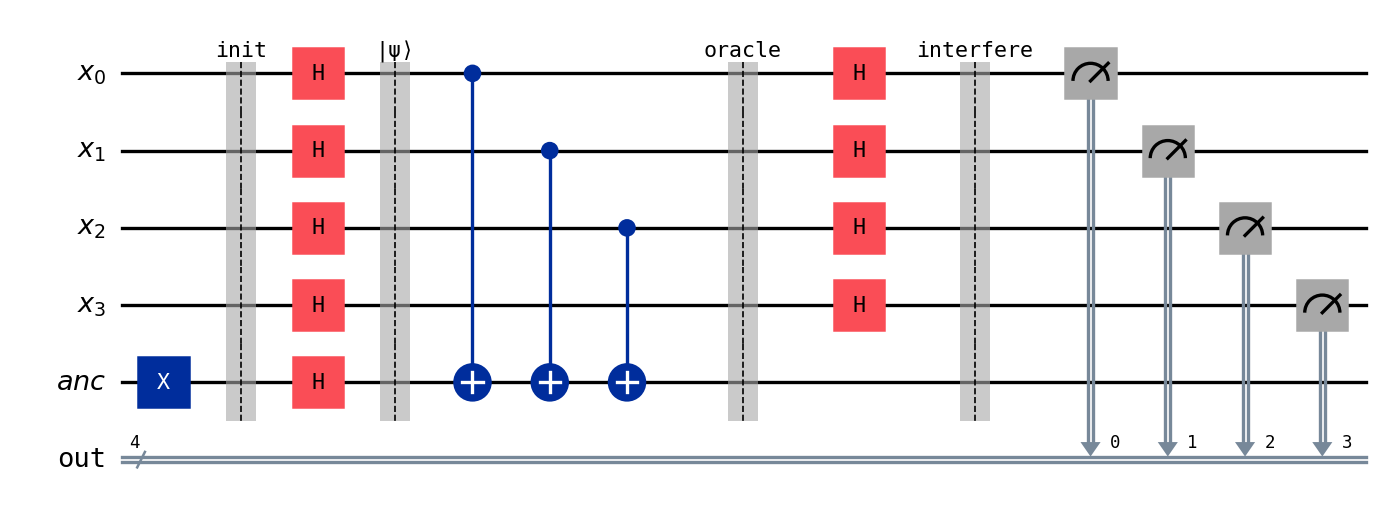

<Figure size 768x576 with 0 Axes>

In [14]:
# ─── 🎮 Your Turn — Modify These Parameters ──────────────────────────────────

YOUR_N_BITS     = 4        # Number of input qubits (try 1-8)
YOUR_ORACLE     = 'balanced'  # 'constant_0', 'constant_1', or 'balanced'
YOUR_SEED       = 99       # Random seed for the balanced oracle pattern
SHOTS           = 2048     # Simulation shots

# ─────────────────────────────────────────────────────────────────────────────

print('╔══════════════════════════════════════════════════════╗')
print('║       🔬 DEUTSCH-JOZSA INTERACTIVE TESTER           ║')
print('╚══════════════════════════════════════════════════════╝\n')

N = 2 ** YOUR_N_BITS
print(f'  Settings: n={YOUR_N_BITS} bits, N={N} inputs, oracle={YOUR_ORACLE}')

# Build and run DJ
qc = build_dj_circuit(YOUR_N_BITS, YOUR_ORACLE, seed=YOUR_SEED, measure=True)
counts = SIM.run(qc, shots=SHOTS).result().get_counts()

all_zeros = '0' * YOUR_N_BITS
top = max(counts, key=counts.get)
verdict = 'CONSTANT' if top == all_zeros else 'BALANCED'
true_type = 'CONSTANT' if 'constant' in YOUR_ORACLE else 'BALANCED'
correct = verdict == true_type

print(f'\n  True oracle type : {true_type}')
print(f'  Top measurement  : |{top}⟩ ({counts[top]}/{SHOTS} shots = {counts[top]/SHOTS:.0%})')
print(f'  D-J verdict      : {verdict}')
print(f'  Correct?         : {"✅ YES" if correct else "❌ NO"}')
print(f'  Classical worst  : {N//2 + 1} queries')
print(f'  Quantum queries  : 1')

# Draw the circuit
print('\n  Circuit diagram:')
display(qc.draw('mpl', style='iqp', fold=50))

# Plot histogram
fig = plot_histogram(counts, title=f'D-J Result — {YOUR_ORACLE} oracle, n={YOUR_N_BITS}',
                     figsize=(10, 4), color='#2196F3')
plt.tight_layout()
plt.show()



### The One-Sentence Pitch
> Deutsch-Jozsa proved for the first time in history that a quantum computer can solve a problem with provably fewer steps than any possible classical algorithm.

### The Engineer Version
> The oracle encodes f(x) into quantum phase. The Hadamard-Oracle-Hadamard sandwich creates constructive interference for ∣0...0⟩ if f is constant, and destructive interference for ∣0...0⟩ if f is balanced. One measurement distinguishes the two cases with zero probability of error.

### Real-World Relevance
- **Sensor fault detection** (as simulated here)
- **Database record integrity** is a hash function constant (broken) or properly varied?
- **Cryptographic function auditing** is a function predictable or truly random-looking?
- **Foundation of Shor's algorithm** the same interference principle breaks RSA encryption

---

| What You Learned | Qiskit Tool |
|---|---|
| Superposition via Hadamard | `qc.h(qubit)` |
| Oracle as CNOT pattern | `qc.cx(control, target)` |
| Phase kickback concept | Ancilla qubit init to ∣1⟩ |
| Interference pattern | Two-stage Hadamard sandwich |
| Simulation & measurement | `AerSimulator`, `plot_histogram` |
| Statevector inspection | `Statevector.from_instruction` |

---
*Built with Qiskit Aer*